# Bài giảng: Hệ Phương trình Tuyến tính và Ma trận - Từ Đại số đến Hình học

Chào mừng các bạn đến với buổi học hôm nay. Chủ đề của chúng ta là một trong những nền tảng của toán học ứng dụng và khoa học máy tính: **Hệ phương trình tuyến tính**. Chúng ta sẽ không chỉ học cách giải chúng, mà còn "nhìn thấy" chúng hoạt động như thế nào thông qua trực quan hóa và khám phá mối liên hệ mật thiết với một công cụ cực kỳ mạnh mẽ: **Ma trận**.

## 1. Hệ Phương trình Tuyến tính là gì? (Ví dụ 2D)

Về cơ bản, một hệ phương trình tuyến tính là một tập hợp các phương trình, trong đó mỗi phương trình là một đường thẳng (trong không gian 2D), một mặt phẳng (trong không gian 3D), hoặc một siêu phẳng (trong không gian nhiều chiều hơn).

Hãy bắt đầu với một ví dụ đơn giản trong không gian 2 chiều:

$$
\begin{cases}
x + y = 3 \\
x - y = 1
\end{cases}
$$

**Ý nghĩa hình học:**
*   Mỗi phương trình, ví dụ `x + y = 3`, biểu diễn một **đường thẳng** trên mặt phẳng tọa độ.
*   Nghiệm của hệ phương trình chính là **giao điểm** của tất cả các đường thẳng này. Đó là điểm `(x, y)` duy nhất thỏa mãn *tất cả* các phương trình cùng một lúc.

### Trực quan hóa hệ phương trình 2D

Chúng ta có thể dễ dàng vẽ hai đường thẳng này để tìm giao điểm của chúng.


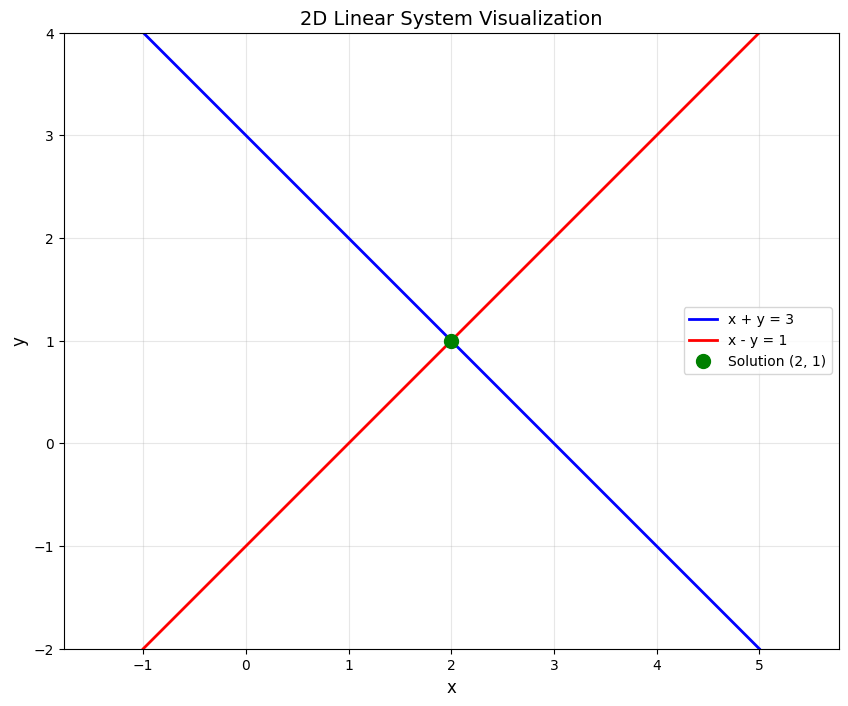

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import matplotlib
import matplotlib
matplotlib.set_loglevel("ERROR")  # Only show errors, not warnings

# Define x range
x = np.linspace(-1, 5, 100)

# Define equations: x + y = 3 and x - y = 1
# Solve for y: y1 = 3 - x, y2 = x - 1
y1 = 3 - x  # From x + y = 3
y2 = x - 1  # From x - y = 1

# Create the plot
plt.figure(figsize=(10, 8))
plt.plot(x, y1, 'b-', linewidth=2, label='x + y = 3')
plt.plot(x, y2, 'r-', linewidth=2, label='x - y = 1')

# Find and mark intersection point
# Solving: x + y = 3 and x - y = 1
# Adding equations: 2x = 4, so x = 2
# Substituting: y = 3 - 2 = 1
intersection_x, intersection_y = 2, 1
plt.plot(intersection_x, intersection_y, 'go', markersize=10, label=f'Solution ({intersection_x}, {intersection_y})')

plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('2D Linear System Visualization', fontsize=14)
plt.legend()
plt.axis('equal')
plt.xlim(-1, 5)
plt.ylim(-2, 4)
plt.show()


**Kết quả trực quan:** Bạn sẽ thấy hai đường thẳng cắt nhau tại một điểm duy nhất. Điểm đó chính là nghiệm `(2, 1)` của hệ phương trình.



## 2. Cầu nối đến Ma trận

Việc viết đi viết lại các biến `x`, `y` khá tốn công. Có một cách biểu diễn hệ phương trình gọn gàng và mạnh mẽ hơn nhiều: sử dụng ma trận.

Hệ phương trình của chúng ta:
$$
\begin{cases}
1x + 1y = 3 \\
1x - 1y = 1
\end{cases}
$$

Có thể được viết lại dưới dạng phương trình ma trận $Ax = b$:

$$
\underbrace{
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
}_{A}
\underbrace{
\begin{pmatrix}
x \\
y
\end{pmatrix}
}_{x}
=
\underbrace{
\begin{pmatrix}
3 \\
1
\end{pmatrix}
}_{b}
$$

Trong đó:
*   $A$ là **ma trận hệ số** (matrix of coefficients).
*   $x$ là **vector ẩn** (vector of variables).
*   $b$ là **vector kết quả** (vector of constants).

Cách biểu diễn này không chỉ gọn gàng, nó còn mở ra một thế giới mới của các phép toán đại số tuyến tính mà chúng ta có thể áp dụng để giải hệ phương trình một cách hệ thống.

Để giải hệ này, chúng ta thường làm việc với **ma trận mở rộng** (augmented matrix), là sự kết hợp của $A$ và $b$:

$$
[A|b] = \left[
\begin{array}{cc|c}
1 & 1 & 3 \\
1 & -1 & 1
\end{array}
\right]
$$

Bây giờ, mọi thao tác chúng ta thực hiện trên hệ phương trình đều có một phép toán tương ứng trên các hàng của ma trận này.

## 3. Các Phép toán và sự Tương ứng

Đây là phần thú vị nhất. Chúng ta sẽ xem xét các phép toán cơ bản để giải hệ phương trình (phép khử Gauss) và xem chúng trông như thế nào trong cả hai "thế giới": thế giới phương trình và thế giới ma trận, cùng với hình ảnh trực quan.

### Phép toán 1: Tráo đổi hai hàng (Row Swapping)

| Thế giới Phương trình | Thế giới Ma trận |
| :--- | :--- |
| Tráo đổi vị trí của hai phương trình. Điều này rõ ràng không làm thay đổi nghiệm của hệ. | Tráo đổi vị trí của hai hàng trong ma trận mở rộng. |
| $\begin{cases} x + y = 3 \\ x - y = 1 \end{cases} \rightarrow \begin{cases} x - y = 1 \\ x + y = 3 \end{cases}$ | $\left[ \begin{array}{cc|c} 1 & 1 & 3 \\ 1 & -1 & 1 \end{array} \right] \xrightarrow{R_1 \leftrightarrow R_2} \left[ \begin{array}{cc|c} 1 & -1 & 1 \\ 1 & 1 & 3 \end{array} \right]$ |

**Trực quan hóa:**
Phép toán này không hề thay đổi hình học. Các đường thẳng vẫn ở nguyên vị trí, giao điểm vẫn vậy. Hình ảnh trực quan sẽ giống hệt hình ảnh ban đầu.


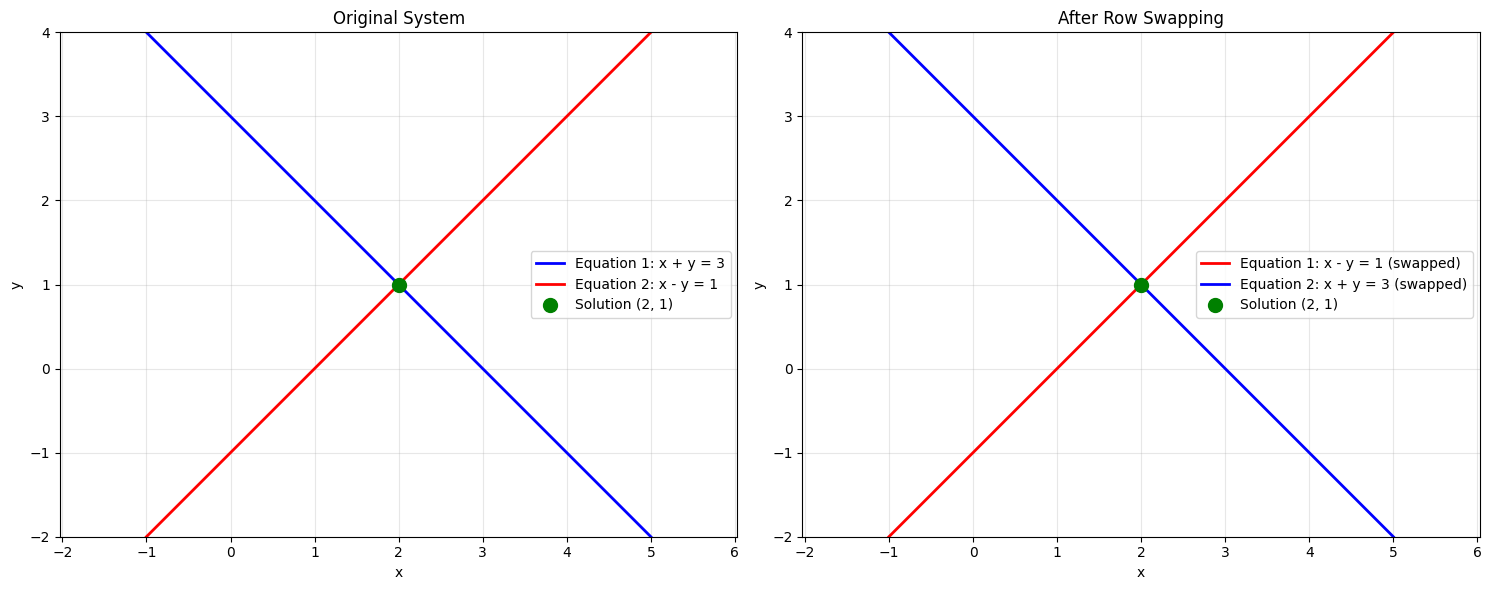

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Define x range
x = np.linspace(-1, 5, 100)

# Original system equations
y1 = 3 - x  # x + y = 3
y2 = x - 1  # x - y = 1

# Create subplot to show before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original system
ax1.plot(x, y1, 'b-', linewidth=2, label='Equation 1: x + y = 3')
ax1.plot(x, y2, 'r-', linewidth=2, label='Equation 2: x - y = 1')
ax1.plot(2, 1, 'go', markersize=10, label='Solution (2, 1)')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original System')
ax1.legend()
ax1.axis('equal')
ax1.set_xlim(-1, 5)
ax1.set_ylim(-2, 4)

# After row swapping (just different order, same lines)
ax2.plot(x, y2, 'r-', linewidth=2, label='Equation 1: x - y = 1 (swapped)')
ax2.plot(x, y1, 'b-', linewidth=2, label='Equation 2: x + y = 3 (swapped)')
ax2.plot(2, 1, 'go', markersize=10, label='Solution (2, 1)')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('After Row Swapping')
ax2.legend()
ax2.axis('equal')
ax2.set_xlim(-1, 5)
ax2.set_ylim(-2, 4)

plt.tight_layout()
plt.show()


### Phép toán 2: Nhân một hàng với một hằng số khác 0 (Row Scaling)

| Thế giới Phương trình | Thế giới Ma trận |
| :--- | :--- |
| Nhân cả hai vế của một phương trình với một số. Đường thẳng biểu diễn phương trình đó không hề thay đổi. | Nhân tất cả các phần tử của một hàng với một số. |
| Nhân phương trình thứ hai với 2: $\begin{cases} x + y = 3 \\ 2(x - y) = 2(1) \end{cases} \rightarrow \begin{cases} x + y = 3 \\ 2x - 2y = 2 \end{cases}$ | Nhân hàng thứ hai với 2: $\left[ \begin{array}{cc|c} 1 & 1 & 3 \\ 1 & -1 & 1 \end{array} \right] \xrightarrow{2R_2 \rightarrow R_2} \left[ \begin{array}{cc|c} 1 & 1 & 3 \\ 2 & -2 & 2 \end{array} \right]$ |

**Trực quan hóa:**
Đường thẳng $x - y = 1$ và $2x - 2y = 2$ là **trùng nhau**. Khi vẽ chúng, bạn sẽ chỉ thấy một đường duy nhất. Giao điểm của hệ mới này với đường thẳng $x+y=3$ vẫn không thay đổi.


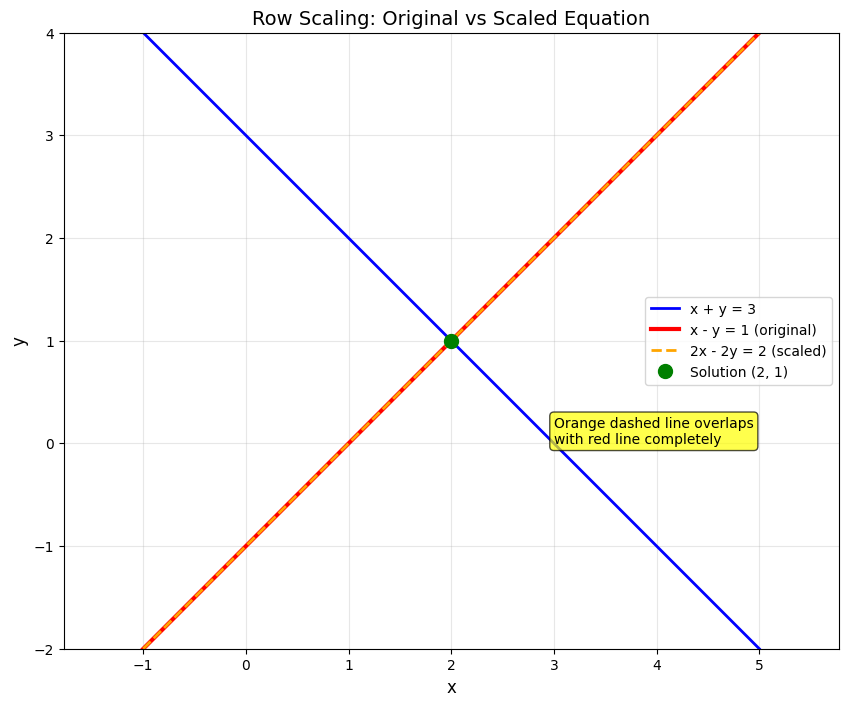

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Define x range
x = np.linspace(-1, 5, 100)

# Original equations
y1 = 3 - x  # x + y = 3
y2 = x - 1  # x - y = 1

# After scaling second equation by 2: 2x - 2y = 2 → y = x - 1 (same line!)
y2_scaled = x - 1  # 2x - 2y = 2 simplified to y = x - 1

plt.figure(figsize=(10, 8))
plt.plot(x, y1, 'b-', linewidth=2, label='x + y = 3')
plt.plot(x, y2, 'r-', linewidth=3, label='x - y = 1 (original)')
plt.plot(x, y2_scaled, 'orange', linewidth=2, linestyle='--', label='2x - 2y = 2 (scaled)')

# Mark intersection point
plt.plot(2, 1, 'go', markersize=10, label='Solution (2, 1)')

plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Row Scaling: Original vs Scaled Equation', fontsize=14)
plt.legend()
plt.axis('equal')
plt.xlim(-1, 5)
plt.ylim(-2, 4)

# Add text annotation
plt.text(3, 0, 'Orange dashed line overlaps\nwith red line completely', 
         fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
plt.show()



*(Trong hình, đường màu cam (phương trình gốc) và đường màu xanh lá (phương trình đã nhân) nằm đè chính xác lên nhau, chứng tỏ chúng biểu diễn cùng một đường thẳng)*

### Phép toán 3: Cộng một bội của hàng khác vào một hàng (Row Combination)

Đây là phép toán "thần kỳ" giúp chúng ta khử các ẩn số.

| Thế giới Phương trình | Thế giới Ma trận |
| :--- | :--- |
| Lấy phương trình này cộng với một bội của phương trình kia để tạo ra một phương trình mới. | Lấy một hàng cộng với một bội của hàng khác để tạo ra một hàng mới. |
| Thay thế Phương trình 2 bằng (Phương trình 2 - Phương trình 1): $\begin{cases} x + y = 3 \\ (x-y) - (x+y) = 1-3 \end{cases} \rightarrow \begin{cases} x + y = 3 \\ -2y = -2 \end{cases}$ | Thay thế Hàng 2 bằng (Hàng 2 - Hàng 1): $\left[ \begin{array}{cc|c} 1 & 1 & 3 \\ 1 & -1 & 1 \end{array} \right] \xrightarrow{R_2 - R_1 \rightarrow R_2} \left[ \begin{array}{cc|c} 1 & 1 & 3 \\ 0 & -2 & -2 \end{array} \right]$ |

**Trực quan hóa:**
Đây là bước trực quan hóa quan trọng nhất. Chúng ta đã thay thế đường thẳng $x-y=1$ bằng một đường thẳng hoàn toàn mới: $-2y=-2$, hay $y=1$.

Hệ phương trình mới của chúng ta là:
$$
\begin{cases}
x + y = 3 \\
y = 1
\end{cases}
$$
Điều kỳ diệu là, **giao điểm của hệ mới này vẫn chính là giao điểm của hệ ban đầu**. Chúng ta đã xoay một trong các đường thẳng (đường $x-y=1$ trở thành đường nằm ngang $y=1$) sao cho việc tìm nghiệm trở nên cực kỳ dễ dàng, nhưng không làm thay đổi vị trí giao điểm.


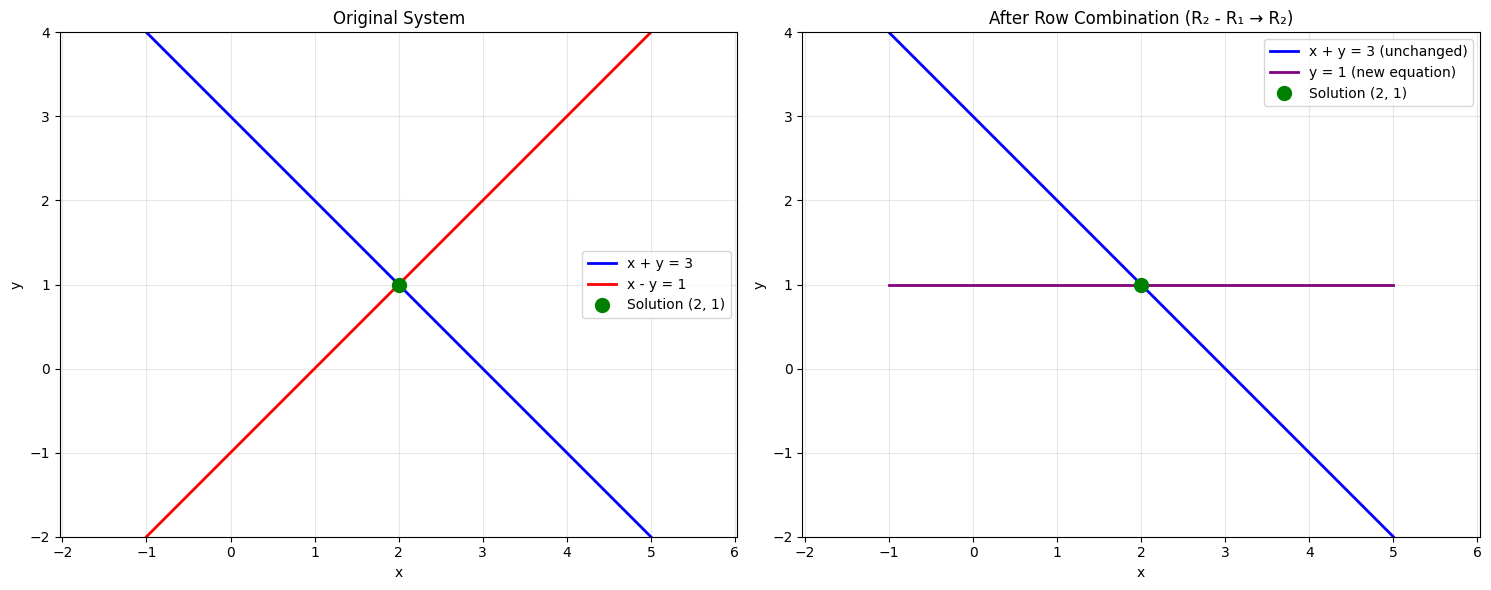

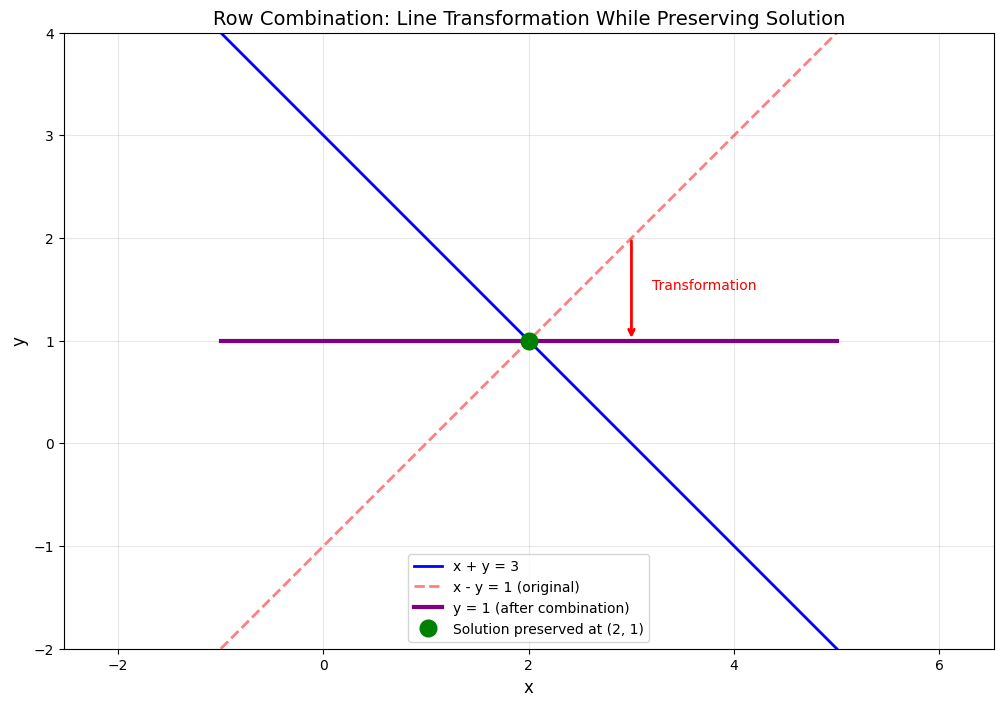

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Define x range
x = np.linspace(-1, 5, 100)

# Original equations
y1 = 3 - x  # x + y = 3
y2 = x - 1  # x - y = 1

# After row combination R2 - R1 → R2: -2y = -2 → y = 1
y2_new = np.ones_like(x)  # y = 1 (horizontal line)

# Create subplot to show transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original system
ax1.plot(x, y1, 'b-', linewidth=2, label='x + y = 3')
ax1.plot(x, y2, 'r-', linewidth=2, label='x - y = 1')
ax1.plot(2, 1, 'go', markersize=10, label='Solution (2, 1)')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original System')
ax1.legend()
ax1.axis('equal')
ax1.set_xlim(-1, 5)
ax1.set_ylim(-2, 4)

# After row combination
ax2.plot(x, y1, 'b-', linewidth=2, label='x + y = 3 (unchanged)')
ax2.plot(x, y2_new, 'purple', linewidth=2, label='y = 1 (new equation)')
ax2.plot(2, 1, 'go', markersize=10, label='Solution (2, 1)')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('After Row Combination (R₂ - R₁ → R₂)')
ax2.legend()
ax2.axis('equal')
ax2.set_xlim(-1, 5)
ax2.set_ylim(-2, 4)

plt.tight_layout()
plt.show()

# Show the transformation step by step
plt.figure(figsize=(12, 8))
plt.plot(x, y1, 'b-', linewidth=2, label='x + y = 3')
plt.plot(x, y2, 'r--', linewidth=2, alpha=0.5, label='x - y = 1 (original)')
plt.plot(x, y2_new, 'purple', linewidth=3, label='y = 1 (after combination)')
plt.plot(2, 1, 'go', markersize=12, label='Solution preserved at (2, 1)')

plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Row Combination: Line Transformation While Preserving Solution', fontsize=14)
plt.legend()
plt.axis('equal')
plt.xlim(-1, 5)
plt.ylim(-2, 4)

# Add arrow to show transformation
plt.annotate('', xy=(3, 1), xytext=(3, 2), 
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
plt.text(3.2, 1.5, 'Transformation', fontsize=10, color='red')
plt.show()


**Hệ ban đầu**


**Hệ sau khi biến đổi** (đường $x-y=1$ được thay bằng đường $y=1$)

*(Giao điểm vẫn được bảo toàn tại (2, 1)!)*

## 4. Mở rộng ra không gian 3 chiều

Bây giờ hãy xem xét một hệ 3 ẩn.
$$
\begin{cases}
2x + y - z = 8 \\
-3x - y + 2z = -11 \\
-2x + y + 2z = -3
\end{cases}
$$

**Ý nghĩa hình học:**
*   Mỗi phương trình bây giờ không phải là đường thẳng nữa, mà là một **mặt phẳng** trong không gian 3D.
*   Nghiệm của hệ là **giao điểm duy nhất** của cả ba mặt phẳng này.

**Biểu diễn ma trận:**
$$
\left[
\begin{array}{ccc|c}
2 & 1 & -1 & 8 \\
-3 & -1 & 2 & -11 \\
-2 & 1 & 2 & -3
\end{array}
\right]
$$

### Trực quan hóa hệ phương trình 3D

Việc trực quan hóa các phép toán trên từng mặt phẳng sẽ khá phức tạp và rối mắt. Thay vào đó, chúng ta sẽ trực quan hóa kết quả cuối cùng: ba mặt phẳng cắt nhau tại một điểm.


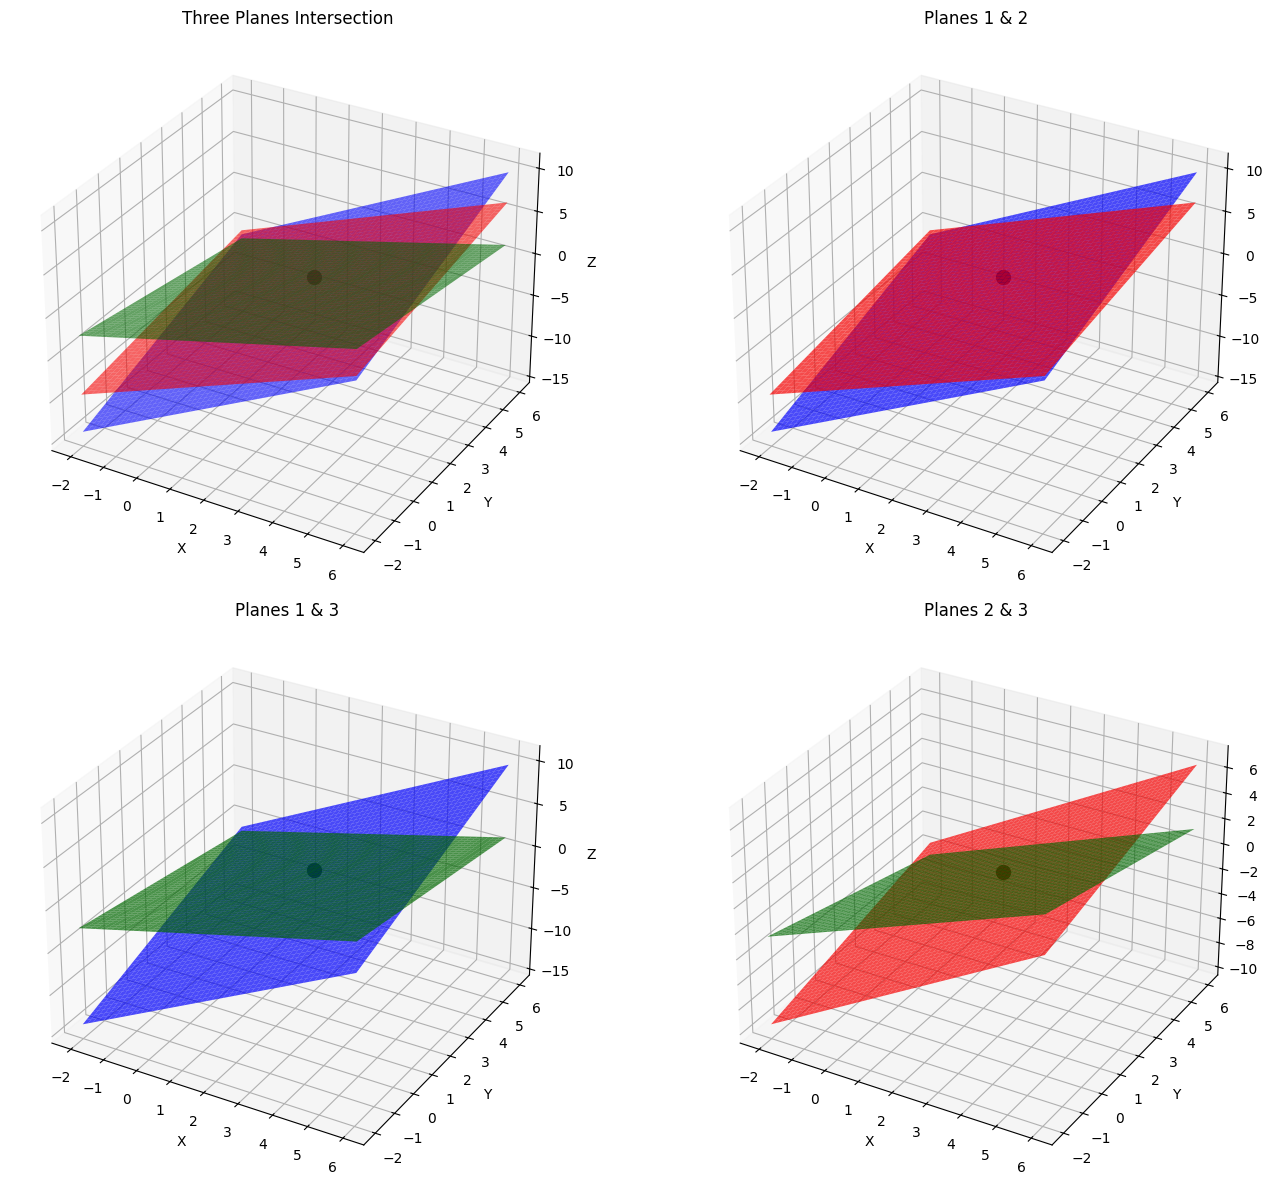

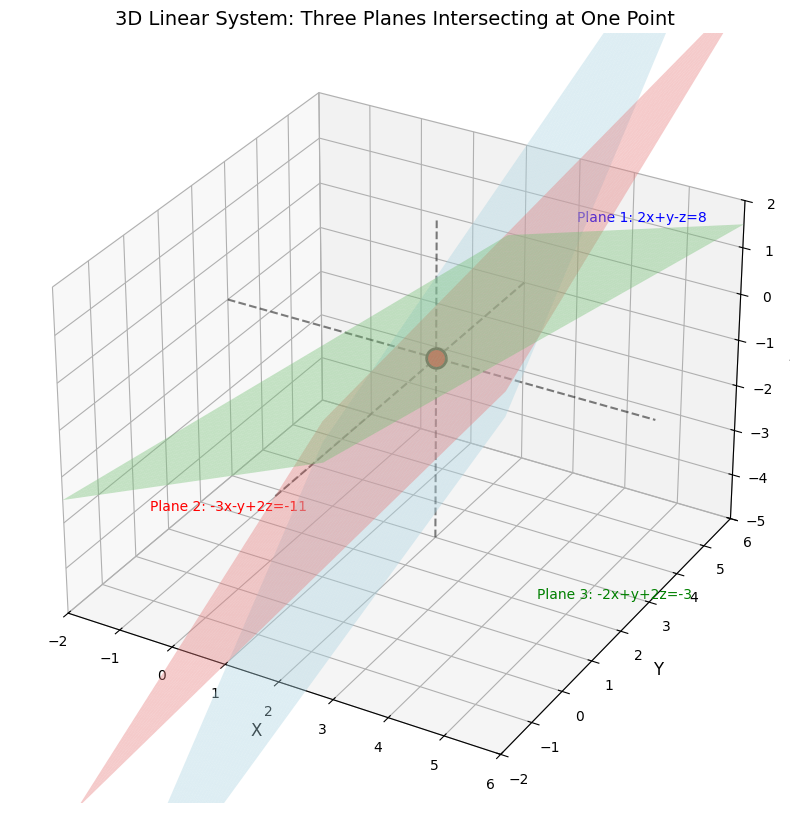

Verification of solution (2, 3, -1):
Equation 1: 2(2) + 3 - (-1) = 8 = 8 ✓
Equation 2: -3(2) - 3 + 2(-1) = -11 = -11 ✓
Equation 3: -2(2) + 3 + 2(-1) = -3 = -3 ✓


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the system of equations:
# 2x + y - z = 8    → z = 2x + y - 8
# -3x - y + 2z = -11 → z = (3x + y - 11) / 2  
# -2x + y + 2z = -3  → z = (2x - y - 3) / 2

# Create meshgrid for x and y
x = np.linspace(-2, 6, 50)
y = np.linspace(-2, 6, 50)
X, Y = np.meshgrid(x, y)

# Calculate z values for each plane
Z1 = 2*X + Y - 8           # First plane: 2x + y - z = 8
Z2 = (3*X + Y - 11) / 2    # Second plane: -3x - y + 2z = -11
Z3 = (2*X - Y - 3) / 2     # Third plane: -2x + y + 2z = -3

# Create 3D plot
fig = plt.figure(figsize=(15, 12))

# First subplot: All three planes
ax1 = fig.add_subplot(221, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z1, alpha=0.6, color='blue', label='Plane 1')
surf2 = ax1.plot_surface(X, Y, Z2, alpha=0.6, color='red', label='Plane 2')
surf3 = ax1.plot_surface(X, Y, Z3, alpha=0.6, color='green', label='Plane 3')

# Mark the intersection point (solution: x=2, y=3, z=-1)
ax1.scatter([2], [3], [-1], color='black', s=100, label='Solution (2,3,-1)')

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Three Planes Intersection')

# Second subplot: Two planes at a time
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_surface(X, Y, Z1, alpha=0.7, color='blue')
ax2.plot_surface(X, Y, Z2, alpha=0.7, color='red')
ax2.scatter([2], [3], [-1], color='black', s=100)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Planes 1 & 2')

ax3 = fig.add_subplot(223, projection='3d')
ax3.plot_surface(X, Y, Z1, alpha=0.7, color='blue')
ax3.plot_surface(X, Y, Z3, alpha=0.7, color='green')
ax3.scatter([2], [3], [-1], color='black', s=100)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Planes 1 & 3')

ax4 = fig.add_subplot(224, projection='3d')
ax4.plot_surface(X, Y, Z2, alpha=0.7, color='red')
ax4.plot_surface(X, Y, Z3, alpha=0.7, color='green')
ax4.scatter([2], [3], [-1], color='black', s=100)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('Planes 2 & 3')

plt.tight_layout()
plt.show()

# Create a more detailed single plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the three planes with different colors and transparency
surf1 = ax.plot_surface(X, Y, Z1, alpha=0.4, color='lightblue', 
                       label='2x + y - z = 8')
surf2 = ax.plot_surface(X, Y, Z2, alpha=0.4, color='lightcoral', 
                       label='-3x - y + 2z = -11')
surf3 = ax.plot_surface(X, Y, Z3, alpha=0.4, color='lightgreen', 
                       label='-2x + y + 2z = -3')

# Plot the intersection point prominently
ax.scatter([2], [3], [-1], color='red', s=200, 
          label='Intersection Point (2, 3, -1)', edgecolors='black', linewidth=2)

# Add coordinate lines to the intersection point
ax.plot([2, 2], [3, 3], [-5, 2], 'k--', alpha=0.5)
ax.plot([2, 2], [-2, 6], [-1, -1], 'k--', alpha=0.5)
ax.plot([-2, 6], [3, 3], [-1, -1], 'k--', alpha=0.5)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.set_title('3D Linear System: Three Planes Intersecting at One Point', fontsize=14)

# Set the viewing limits
ax.set_xlim(-2, 6)
ax.set_ylim(-2, 6)
ax.set_zlim(-5, 2)

# Add text annotations for each plane
ax.text(4, 4, 2, 'Plane 1: 2x+y-z=8', fontsize=10, color='blue')
ax.text(-1, -1, -3, 'Plane 2: -3x-y+2z=-11', fontsize=10, color='red')
ax.text(5, 1, -4, 'Plane 3: -2x+y+2z=-3', fontsize=10, color='green')

plt.show()

# # Verify the solution
# print("Verification of solution (2, 3, -1):")
# print(f"Equation 1: 2(2) + 3 - (-1) = {2*2 + 3 - (-1)} = 8 ✓")
# print(f"Equation 2: -3(2) - 3 + 2(-1) = {-3*2 - 3 + 2*(-1)} = -11 ✓")
# print(f"Equation 3: -2(2) + 3 + 2(-1) = {-2*2 + 3 + 2*(-1)} = -3 ✓")


**Kết quả trực quan:** Bạn sẽ thấy ba mặt phẳng có màu khác nhau, nghiêng theo các hướng khác nhau trong không gian 3D. Chúng sẽ cùng đi qua một điểm duy nhất, được đánh dấu nổi bật. Điểm đó chính là nghiệm `(2, 3, -1)`.



## 5. Kết luận

Qua bài giảng hôm nay, chúng ta đã thấy được rằng:
1.  **Hệ phương trình tuyến tính có một bản chất hình học sâu sắc**: Chúng là giao điểm của các đường thẳng, mặt phẳng, hoặc siêu phẳng.
2.  **Ma trận là ngôn ngữ tự nhiên để biểu diễn và giải quyết hệ phương trình**: Nó cô đọng, hệ thống và hiệu quả cho tính toán.
3.  **Mỗi phép toán đại số (khử Gauss) đều tương ứng với một phép biến đổi hình học**: Các phép biến đổi này có thể thay đổi hình dạng của các đường thẳng/mặt phẳng, nhưng chúng luôn **bảo toàn nghiệm** của hệ.

Việc trực quan hóa không chỉ giúp chúng ta "tin" vào kết quả, mà còn giúp chúng ta xây dựng một trực giác mạnh mẽ về cách các khái niệm đại số trừu tượng hoạt động trong thế giới hình học thực tế.

Chắc chắn rồi! Tiếp nối bài giảng trước, chúng ta sẽ đi sâu vào một khía cạnh cực kỳ mạnh mẽ và đẹp đẽ của ma trận: khả năng **biến đổi không gian**.

***

# Bài giảng (Phần 2): Ma trận như những Phép biến đổi Hình học

Ở phần trước, chúng ta đã xem ma trận như một cách "gọn gàng" để viết lại hệ phương trình. Hôm nay, chúng ta sẽ thay đổi góc nhìn. Hãy xem ma trận không phải là một đối tượng tĩnh, mà là một **hành động**, một **phép biến đổi** làm thay đổi mọi điểm, mọi vector, và mọi hình dạng trong không gian.

## 1. Ý tưởng Cốt lõi: Phép nhân Ma trận là một Phép biến đổi

Khi chúng ta nhân một ma trận $M$ với một vector $v$, chúng ta sẽ nhận được một vector mới $v'$:

$$
Mv = v'
$$

Đây không chỉ là một phép tính. Về mặt hình học, đây là một hành động **di chuyển** vector $v$ đến một vị trí mới $v'$. Nếu chúng ta làm điều này với *mọi* vector trong không gian, toàn bộ không gian sẽ bị co giãn, quay, hoặc biến dạng theo một quy tắc nhất định do ma trận $M$ quyết định.

Để hiểu rõ một phép biến đổi, chúng ta chỉ cần xem nó tác động lên các **vector cơ sở** (basis vectors). Trong không gian 2D, đó là $\hat{i} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$ (vector đơn vị trên trục x) và $\hat{j} = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$ (vector đơn vị trên trục y).

Hãy xem một ma trận $A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$ làm gì với chúng:

$$
A \hat{i} = \begin{pmatrix} a & b \\ c & d \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} a \\ c \end{pmatrix} \quad (\text{Cột đầu tiên của A})
$$
$$
A \hat{j} = \begin{pmatrix} a & b \\ c & d \end{pmatrix} \begin{pmatrix} 0 \\ 1 \end{pmatrix} = \begin{pmatrix} b \\ d \end{pmatrix} \quad (\text{Cột thứ hai của A})
$$
**Điều này cực kỳ quan trọng:** Các cột của một ma trận cho chúng ta biết vị trí mới của các vector cơ sở sau khi biến đổi.

Bây giờ, hãy cùng khám phá và trực quan hóa một số phép biến đổi cơ bản. Chúng ta sẽ sử dụng một hình vuông đơn vị để xem nó bị biến đổi như thế nào.

## 2. Phép toán 1: Phép Co giãn (Scaling)

Phép co giãn làm "kéo dài" hoặc "co lại" không gian dọc theo các trục.

*   **Ma trận:** $S = \begin{pmatrix} s_x & 0 \\ 0 & s_y \end{pmatrix}$
*   **Tác động:**
    *   $s_x$: Hệ số co giãn theo trục x.
    *   $s_y$: Hệ số co giãn theo trục y.

**Ví dụ:** Co giãn không gian gấp 2 lần theo trục x và 0.5 lần theo trục y.
Ma trận biến đổi là: $S = \begin{pmatrix} 2 & 0 \\ 0 & 0.5 \end{pmatrix}$.

### Trực quan hóa Phép co giãn

Chúng ta sẽ xem ma trận này làm gì với một hình vuông đơn vị.
*   Hình vuông ban đầu có các đỉnh tại (0,0), (1,0), (1,1), (0,1).
*   Vector cơ sở $\hat{i}$ sẽ di chuyển đến $\begin{pmatrix} 2 \\ 0 \end{pmatrix}$.
*   Vector cơ sở $\hat{j}$ sẽ di chuyển đến $\begin{pmatrix} 0 \\ 0.5 \end{pmatrix}$.
*   Hình vuông sẽ biến thành một hình chữ nhật.


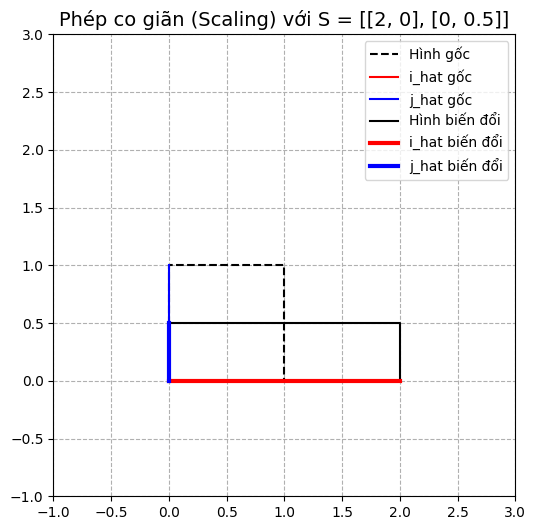

In [23]:
# Visualization Code for Scaling
import numpy as np
import matplotlib.pyplot as plt

def plot_transformation(matrix, title=""):
    # Define the original unit square and basis vectors
    square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
    i_hat = np.array([[0, 1], [0, 0]])
    j_hat = np.array([[0, 0], [0, 1]])

    # Apply the transformation
    transformed_square = matrix @ square
    transformed_i = matrix @ i_hat
    transformed_j = matrix @ j_hat

    # Plotting
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')
    
    # Plot original
    ax.plot(square[0], square[1], 'k--', label='Hình gốc')
    ax.plot(i_hat[0], i_hat[1], 'r-', label='i_hat gốc')
    ax.plot(j_hat[0], j_hat[1], 'b-', label='j_hat gốc')
    
    # Plot transformed
    ax.plot(transformed_square[0], transformed_square[1], 'k-', label='Hình biến đổi')
    ax.plot(transformed_i[0], transformed_i[1], 'r-', linewidth=3, label='i_hat biến đổi')
    ax.plot(transformed_j[0], transformed_j[1], 'b-', linewidth=3, label='j_hat biến đổi')
    
    ax.set_xlim(-1, 3)
    ax.set_ylim(-1, 3)
    ax.grid(True, linestyle='--')
    ax.legend()
    ax.set_title(title, fontsize=14)
    plt.show()

# Define the scaling matrix
S = np.array([[2, 0], [0, 0.5]])
plot_transformation(S, title="Phép co giãn (Scaling) với S = [[2, 0], [0, 0.5]]")


**Kết quả trực quan:** Bạn sẽ thấy hình vuông màu đen nét đứt bị kéo dài theo chiều ngang và co lại theo chiều dọc để trở thành hình chữ nhật màu đen nét liền. Các vector cơ sở màu đỏ và xanh cũng thay đổi độ dài tương ứng.

## 3. Phép toán 2: Phép Quay (Rotation)

Phép quay sẽ xoay toàn bộ không gian quanh gốc tọa độ một góc $\theta$.

*   **Ma trận:** $R = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$
*   **Tác động:** Quay ngược chiều kim đồng hồ một góc $\theta$.

**Ví dụ:** Quay không gian một góc 45 độ ($\pi/4$ radians).
$\cos(45^\circ) = \sin(45^\circ) \approx 0.707$.
Ma trận biến đổi là: $R = \begin{pmatrix} 0.707 & -0.707 \\ 0.707 & 0.707 \end{pmatrix}$.

### Trực quan hóa Phép quay


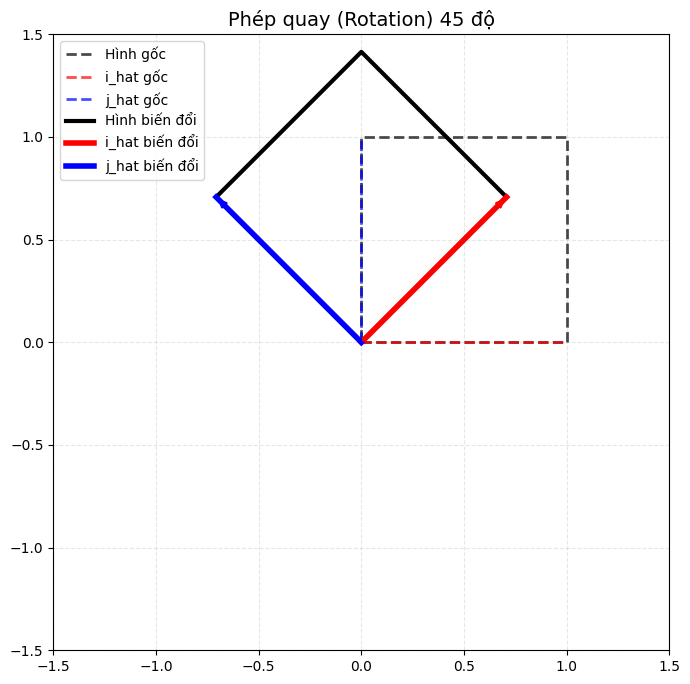

In [26]:
# Visualization Code for Rotation
# We can reuse the plot_transformation function from above.
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', message='Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.')

# Define the rotation angle (45 degrees in radians)
theta = np.pi / 4
c, s = np.cos(theta), np.sin(theta)

# Define the rotation matrix
R = np.array([[c, -s], [s, c]])

def plot_transformation(matrix, title=""):
    # Define the original unit square and basis vectors
    square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
    i_hat = np.array([[0, 1], [0, 0]])
    j_hat = np.array([[0, 0], [0, 1]])

    # Apply the transformation
    transformed_square = matrix @ square
    transformed_i = matrix @ i_hat
    transformed_j = matrix @ j_hat

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    
    # Plot original
    ax.plot(square[0], square[1], 'k--', linewidth=2, label='Hình gốc', alpha=0.7)
    ax.plot(i_hat[0], i_hat[1], 'r--', linewidth=2, label='i_hat gốc', alpha=0.7)
    ax.plot(j_hat[0], j_hat[1], 'b--', linewidth=2, label='j_hat gốc', alpha=0.7)
    
    # Plot transformed
    ax.plot(transformed_square[0], transformed_square[1], 'k-', linewidth=3, label='Hình biến đổi')
    ax.plot(transformed_i[0], transformed_i[1], 'r-', linewidth=4, label='i_hat biến đổi')
    ax.plot(transformed_j[0], transformed_j[1], 'b-', linewidth=4, label='j_hat biến đổi')
    
    # Add arrows to show direction of basis vectors
    ax.annotate('', xy=transformed_i[:, 1], xytext=(0, 0), 
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.annotate('', xy=transformed_j[:, 1], xytext=(0, 0), 
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_title(title, fontsize=14)
    plt.show()

plot_transformation(R, title="Phép quay (Rotation) 45 độ")


**Kết quả trực quan:** Toàn bộ hình vuông và các vector cơ sở sẽ được xoay 45 độ quanh gốc tọa độ. Hình dạng và kích thước của hình vuông không đổi, chỉ có hướng của nó thay đổi.

## 4. Phép toán 3: Phép Biến dạng trượt (Shearing)

Phép biến dạng trượt làm "nghiêng" không gian, giống như bạn đẩy một chồng sách.

*   **Ma trận (Trượt ngang):** $H = \begin{pmatrix} 1 & k \\ 0 & 1 \end{pmatrix}$
*   **Tác động:**
    *   Giữ nguyên trục x.
    *   Mỗi điểm $(x, y)$ bị đẩy sang ngang một đoạn bằng $k \cdot y$. Càng ở xa trục x, điểm bị đẩy càng nhiều.

**Ví dụ:** Trượt ngang với hệ số $k=1.5$.
Ma trận biến đổi là: $H = \begin{pmatrix} 1 & 1.5 \\ 0 & 1 \end{pmatrix}$.

### Trực quan hóa Phép biến dạng trượt


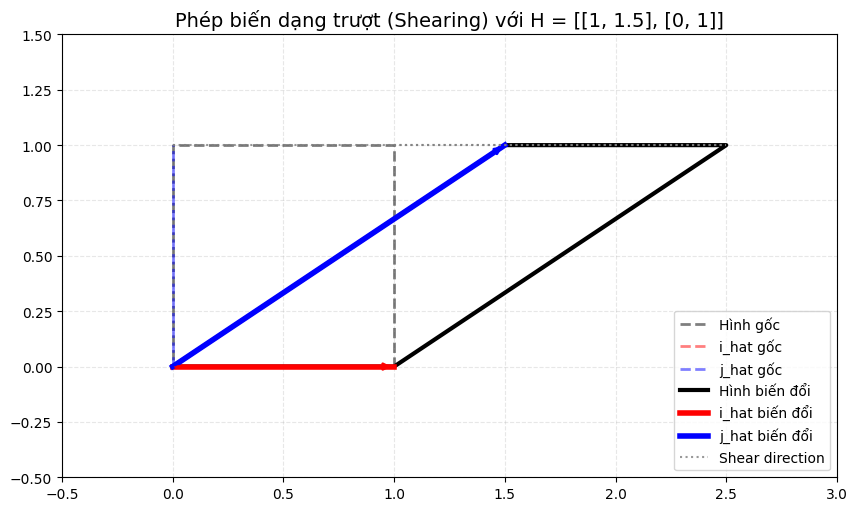

In [27]:
# Visualization Code for Shearing
# We can reuse the plot_transformation function.
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', message='Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.')

def plot_transformation_shear(matrix, title=""):
    # Define the original unit square and basis vectors
    square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
    i_hat = np.array([[0, 1], [0, 0]])
    j_hat = np.array([[0, 0], [0, 1]])

    # Apply the transformation
    transformed_square = matrix @ square
    transformed_i = matrix @ i_hat
    transformed_j = matrix @ j_hat

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_aspect('equal')
    
    # Plot original with lighter colors
    ax.plot(square[0], square[1], 'k--', linewidth=2, label='Hình gốc', alpha=0.5)
    ax.plot(i_hat[0], i_hat[1], 'r--', linewidth=2, label='i_hat gốc', alpha=0.5)
    ax.plot(j_hat[0], j_hat[1], 'b--', linewidth=2, label='j_hat gốc', alpha=0.5)
    
    # Plot transformed
    ax.plot(transformed_square[0], transformed_square[1], 'k-', linewidth=3, label='Hình biến đổi')
    ax.plot(transformed_i[0], transformed_i[1], 'r-', linewidth=4, label='i_hat biến đổi')
    ax.plot(transformed_j[0], transformed_j[1], 'b-', linewidth=4, label='j_hat biến đổi')
    
    # Add arrows to show transformation
    ax.annotate('', xy=transformed_i[:, 1], xytext=(0, 0), 
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.annotate('', xy=transformed_j[:, 1], xytext=(0, 0), 
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    
    # Show the shearing effect with dotted lines
    ax.plot([0, transformed_square[0, 2]], [1, transformed_square[1, 2]], 
            'gray', linestyle=':', alpha=0.8, label='Shear direction')
    ax.plot([1, transformed_square[0, 2]], [1, transformed_square[1, 2]], 
            'gray', linestyle=':', alpha=0.8)
    
    ax.set_xlim(-0.5, 3)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_title(title, fontsize=14)
    plt.show()

# Define the shear matrix
H = np.array([[1, 1.5], [0, 1]])
plot_transformation_shear(H, title="Phép biến dạng trượt (Shearing) với H = [[1, 1.5], [0, 1]]")



**Kết quả trực quan:** Bạn sẽ thấy hình vuông bị biến thành một hình bình hành.
*   Vector $\hat{i}$ (trên trục x) không thay đổi.
*   Vector $\hat{j}$ bị "nghiêng" sang phải, đến vị trí $\begin{pmatrix} 1.5 \\ 1 \end{pmatrix}$.
Cạnh dưới của hình vuông nằm yên, trong khi cạnh trên bị trượt sang phải.

## 5. Sức mạnh Thực sự: Kết hợp các Phép biến đổi

Điều tuyệt vời nhất là chúng ta có thể kết hợp nhiều phép biến đổi bằng cách **nhân các ma trận lại với nhau**. Nếu bạn muốn thực hiện phép quay **R** *trước*, rồi đến phép co giãn **S**, ma trận biến đổi tổng hợp sẽ là:

$$
M = S \cdot R
$$

**Lưu ý quan trọng:** Thứ tự nhân ma trận rất quan trọng! $S \cdot R$ (quay trước, giãn sau) thường sẽ cho kết quả khác với $R \cdot S$ (giãn trước, quay sau). Phép biến đổi được áp dụng từ **phải qua trái**.

### Trực quan hóa việc Kết hợp Phép biến đổi

Hãy xem sự khác biệt giữa "Quay rồi Giãn" và "Giãn rồi Quay".


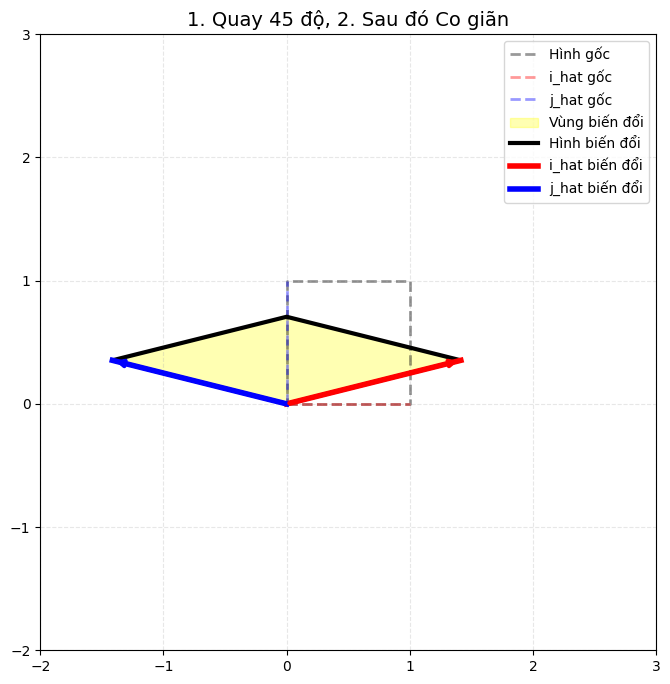

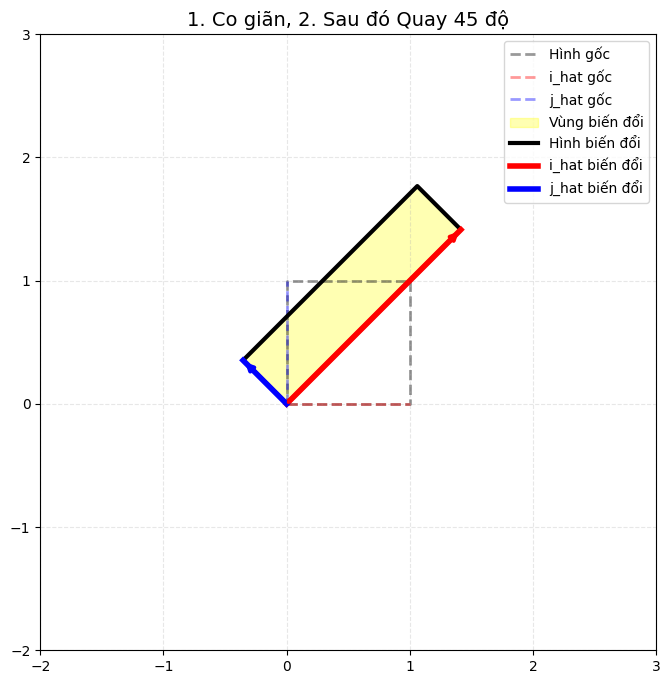

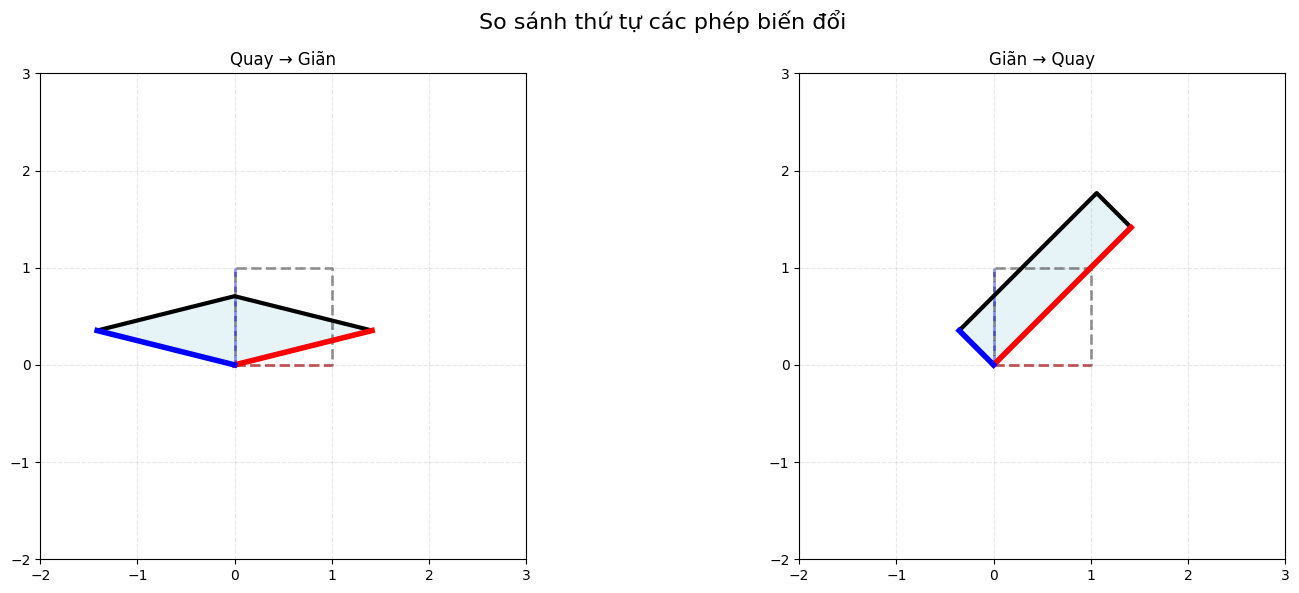

In [28]:
# Visualization Code for Combined Transformations
# We use the matrices S and R defined previously
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', message='Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.')

# Define matrices
S = np.array([[2, 0], [0, 0.5]])  # Scaling matrix
theta = np.pi / 4
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, -s], [s, c]])   # Rotation matrix

def plot_combined_transformation(matrix, title=""):
    # Define the original unit square and basis vectors
    square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
    i_hat = np.array([[0, 1], [0, 0]])
    j_hat = np.array([[0, 0], [0, 1]])

    # Apply the transformation
    transformed_square = matrix @ square
    transformed_i = matrix @ i_hat
    transformed_j = matrix @ j_hat

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    
    # Plot original
    ax.plot(square[0], square[1], 'k--', linewidth=2, label='Hình gốc', alpha=0.4)
    ax.plot(i_hat[0], i_hat[1], 'r--', linewidth=2, label='i_hat gốc', alpha=0.4)
    ax.plot(j_hat[0], j_hat[1], 'b--', linewidth=2, label='j_hat gốc', alpha=0.4)
    
    # Plot transformed
    ax.fill(transformed_square[0], transformed_square[1], alpha=0.3, color='yellow', 
            label='Vùng biến đổi')
    ax.plot(transformed_square[0], transformed_square[1], 'k-', linewidth=3, 
            label='Hình biến đổi')
    ax.plot(transformed_i[0], transformed_i[1], 'r-', linewidth=4, label='i_hat biến đổi')
    ax.plot(transformed_j[0], transformed_j[1], 'b-', linewidth=4, label='j_hat biến đổi')
    
    # Add arrows for basis vectors
    ax.annotate('', xy=transformed_i[:, 1], xytext=(0, 0), 
                arrowprops=dict(arrowstyle='->', color='red', lw=3))
    ax.annotate('', xy=transformed_j[:, 1], xytext=(0, 0), 
                arrowprops=dict(arrowstyle='->', color='blue', lw=3))
    
    ax.set_xlim(-2, 3)
    ax.set_ylim(-2, 3)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_title(title, fontsize=14)
    plt.show()

# Case 1: Rotate then Scale (M1 = S @ R)
M1 = S @ R
plot_combined_transformation(M1, title="1. Quay 45 độ, 2. Sau đó Co giãn")

# Case 2: Scale then Rotate (M2 = R @ S)
M2 = R @ S
plot_combined_transformation(M2, title="1. Co giãn, 2. Sau đó Quay 45 độ")

# Show side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Function for subplot
def plot_on_axis(ax, matrix, title):
    square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
    i_hat = np.array([[0, 1], [0, 0]])
    j_hat = np.array([[0, 0], [0, 1]])
    
    transformed_square = matrix @ square
    transformed_i = matrix @ i_hat
    transformed_j = matrix @ j_hat
    
    ax.set_aspect('equal')
    ax.plot(square[0], square[1], 'k--', linewidth=2, alpha=0.4)
    ax.plot(i_hat[0], i_hat[1], 'r--', linewidth=2, alpha=0.4)
    ax.plot(j_hat[0], j_hat[1], 'b--', linewidth=2, alpha=0.4)
    
    ax.fill(transformed_square[0], transformed_square[1], alpha=0.3, color='lightblue')
    ax.plot(transformed_square[0], transformed_square[1], 'k-', linewidth=3)
    ax.plot(transformed_i[0], transformed_i[1], 'r-', linewidth=4)
    ax.plot(transformed_j[0], transformed_j[1], 'b-', linewidth=4)
    
    ax.set_xlim(-2, 3)
    ax.set_ylim(-2, 3)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_title(title, fontsize=12)

plot_on_axis(ax1, M1, "Quay → Giãn")
plot_on_axis(ax2, M2, "Giãn → Quay")

plt.suptitle("So sánh thứ tự các phép biến đổi", fontsize=16)
plt.tight_layout()
plt.show()


**Kết quả trực quan:** Bạn sẽ nhận được hai đồ thị:
1.  **Quay rồi Giãn:** Hình vuông đầu tiên được quay 45 độ, sau đó hình vuông đã quay này bị kéo dài theo trục x và co lại theo trục y. Kết quả là một hình bình hành thon dài nằm nghiêng.
2.  **Giãn rồi Quay:** Hình vuông đầu tiên bị kéo thành hình chữ nhật, sau đó toàn bộ hình chữ nhật này được quay 45 độ. Kết quả là một hình chữ nhật nằm nghiêng.

Hai kết quả cuối cùng hoàn toàn khác nhau, chứng tỏ thứ tự của các phép biến đổi là cực kỳ quan trọng.

## 6. Mở rộng ra 3D

Tất cả các khái niệm này đều có thể áp dụng cho không gian 3 chiều.
*   Vector cơ sở là $\hat{i}, \hat{j}, \hat{k}$.
*   Ma trận biến đổi là ma trận 3x3.
*   Phép quay sẽ phức tạp hơn, vì chúng ta quay quanh một **trục** (ví dụ: quay quanh trục Z).
    *   Ma trận quay quanh trục Z một góc $\theta$:
        $$ R_z = \begin{pmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{pmatrix} $$
        (Lưu ý: Tọa độ z được giữ nguyên).

## 7. Kết luận

Hôm nay, chúng ta đã khám phá một góc nhìn hoàn toàn mới về ma trận. Chúng không chỉ là các bảng số dùng để giải phương trình, mà còn là một ngôn ngữ mạnh mẽ để mô tả các phép biến đổi hình học:
*   **Scaling (Co giãn):** Kéo dài hoặc co lại không gian.
*   **Rotation (Quay):** Xoay không gian quanh một điểm hoặc một trục.
*   **Shearing (Biến dạng trượt):** Làm nghiêng không gian.

Bằng cách nhân các ma trận, chúng ta có thể tạo ra vô số các phép biến đổi phức tạp, từ đồ họa máy tính, robot học cho đến vật lý. Hiểu được mối liên hệ giữa đại số (phép nhân ma trận) và hình học (sự thay đổi của không gian) là một trong những chìa khóa quan trọng nhất để làm chủ lĩnh vực này.